
# Tracking Multi-Character Emotional Arcs using LabMT

This notebook demonstrates a Digital Humanities pipeline to track single and multi-character emotional arcs in a shory. We use the **labMT sentiment dictionary** (happiness scores 1–9)
and **spaCy dependency parsing** to track character-specific emotional arcs.

**Dependencies**: matplotlib, numpy, spacy (en_core_web_sm)

---
## Kurt Vonnegut's "Shape of Stories"

> *"There is no reason why the simple shapes of stories can't be fed into computers."*
> — Kurt Vonnegut, rejected anthropology thesis (1947)

Vonnegut proposed that every story has a **shape** — a curve of fortune over time.
The labMT dictionary lets us **measure** this shape by scoring each word's happiness (1–9).


## 0. Setup: Load labMT English Lexicon

In [12]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import spacy
from collections import defaultdict
import string  # New import


# ROOT: current working directory of the notebook.
# We assume the notebook and 'labMT-english.csv' live in the same folder.
ROOT = Path.cwd()

# Full path to the single labMT English CSV file.
# The file is expected to have two columns: word,score
LABMT_PATH = Path("labMT-english.csv")

# labmt: dictionary mapping each word (str) to its happiness score (float).
labmt = {}

# Create a translation table to remove punctuation
translator = str.maketrans('', '', string.punctuation)

# Open the labMT file and read it line by line.
with open(LABMT_PATH, encoding="utf-8") as f:
    for line in f:
        # Remove leading/trailing whitespace and newline characters.
        line = line.strip()
        # Skip empty lines.
        if not line:
            continue

        # Split the line into columns.
        # If your file is tab-separated instead of comma-separated,
        # change "," to "\t" here.
        parts = line.split(",")

        # We expect at least two columns: word and score.
        if len(parts) < 2:
            continue

        # First column: word form.
        # Strip whitespace and lowercase so lookups are case-insensitive.
        word = parts[0].strip().lower()

        # Second column: numeric score as string.
        score_str = parts[1].strip()

        # Only add entries that have both a non-empty word and score.
        if word and score_str:
            # Convert score string to float and store in the dictionary.
            labmt[word] = float(score_str)



# --- Quick sanity checks for the loaded dictionary ---

# 1) Print basic information about the dictionary.
print(f"labMT loaded: {len(labmt)} words")

# 2) Print the first 10 (word, score) pairs for inspection.
#    We sort by word to make the output deterministic and easier to read.
first_10_items = list(sorted(labmt.items(), key=lambda x: x[0]))[:10]
print("First 10 entries in labmt (word -> score):")
for w, s in first_10_items:
    print(f"  {w}: {s}")


labMT loaded: 10219 words
First 10 entries in labmt (word -> score):
  #epicpetwars: 4.54
  #fact: 5.3
  #fail: 2.62
  #fb: 5.12
  #ff: 4.64
  #followfriday: 5.24
  #formspringme: 4.54
  #haiti: 4.38
  #idothat2: 4.56
  #in2010: 4.9


## 1. Sentiment Analysis Functions using labMT dictionary
This next cell defines the core functions for sentiment analysis using the `labMT` dictionary:

*   **`STOP_LENS`**: This tuple `(4.0, 6.0)` specifies a 'neutral' interval for sentiment scores. Words whose happiness scores fall within this range are considered neutral and are excluded from the analysis. This helps focus on words with more distinct positive or negative connotations.

*   **`happiness(text: str)`**: This function calculates the average happiness score for a given text. It processes the text by lowercasing words, removing punctuation, and then looks up each word in the `labMT` dictionary. Only words with scores *outside* the `STOP_LENS` interval contribute to the average. If no contributing words are found, it returns a default neutral score of 5.0.

*   **`word_contributions(text: str)`**: This helper function provides a detailed breakdown of which words actually contribute to the `happiness` score. It applies the same filtering logic as the `happiness` function but instead returns a list of `(word, score)` pairs for all words that are found in `labMT` and have scores outside the neutral `STOP_LENS`.

In [13]:
# STOP_LENS defines the "neutral" score interval.
# Words whose scores fall inside this range will be excluded from analysis.
# This follows the Hedonometer / labMT convention.
STOP_LENS = (4.0, 6.0)  # neutral band; we keep only clearly positive/negative words


def happiness(text: str) -> float:
    """
    Compute the average labMT happiness score for a given text.

    Steps:
    1. Lowercase and split the text into whitespace-separated tokens.
    2. For each word, if it appears in labmt and its score is
       outside the neutral interval [STOP_LENS[0], STOP_LENS[1]],
       include its score in the list.
    3. Return the mean of the remaining scores.
       If there are no contributing words, return 5.0 as a neutral default.
    """
    # Lowercase and tokenize the text into words.
    clean_text = text.translate(translator).lower()
    words = clean_text.split()

    # Collect scores for words that:
    # - exist in the labmt dictionary, and
    # - are outside the neutral stop-lens interval.
    scores = [
        labmt[w]
        for w in words
        if w in labmt and not (STOP_LENS[0] <= labmt[w] <= STOP_LENS[1])
    ]

    # If we have at least one contributing word, return the mean score.
    # Otherwise, fall back to a neutral value of 5.0.
    return np.mean(scores) if scores else 5.0


def word_contributions(text: str):
    """
    Return the list of (word, score) pairs that contribute to the happiness score.

    This function mirrors the filtering logic in `happiness`, but instead of
    collapsing everything into a single mean value, it exposes which words
    actually contribute and what their individual scores are.

    Returns:
        List of (word, score) tuples for all words in `text` that:
        - are found in the labmt dictionary, and
        - have scores outside the neutral STOP_LENS interval.
    """
    # Remove punctuation and lowercase before splitting
    clean_text = text.translate(translator).lower()
    words = clean_text.split()

    return [
        (w, labmt[w])
        for w in words
        if w in labmt and not (STOP_LENS[0] <= labmt[w] <= STOP_LENS[1])
    ]

---
## 1.  Multi-Character Story


We visualize the computed happiness scores for this multi_character story. It uses `matplotlib` to plot the sentiment arc over the sentences, highlighting the changes in happiness. A neutral line at 5.0 is added for reference, and each data point is annotated with its corresponding sentence label and score.

S1 [h=7.13]: adventure(7.3), together(6.8), shared(6.8), excitement(7.6)
S2 [h=7.14]: found(6.5), safe(7.0), great(7.9), relief(6.9), hope(7.4), home(7.1)
S3 [h=4.52]: celebrated(7.8), courage(7.5), terrible(2.8), fear(2.3), agony(2.2)
S4 [h=6.74]: she(6.2), forward(6.1), brilliant(7.7), determination(7.0)
S5 [h=3.08]: fell(3.2), dark(3.8), despair(2.8), suffered(2.2), alone(3.3)
S6 [h=7.56]: reached(6.1), glorious(7.7), laughed(8.3), joy(8.2)
S7 [h=3.49]: lost(2.8), forever(6.5), cruel(1.8), hopeless(2.6), darkness(3.8)


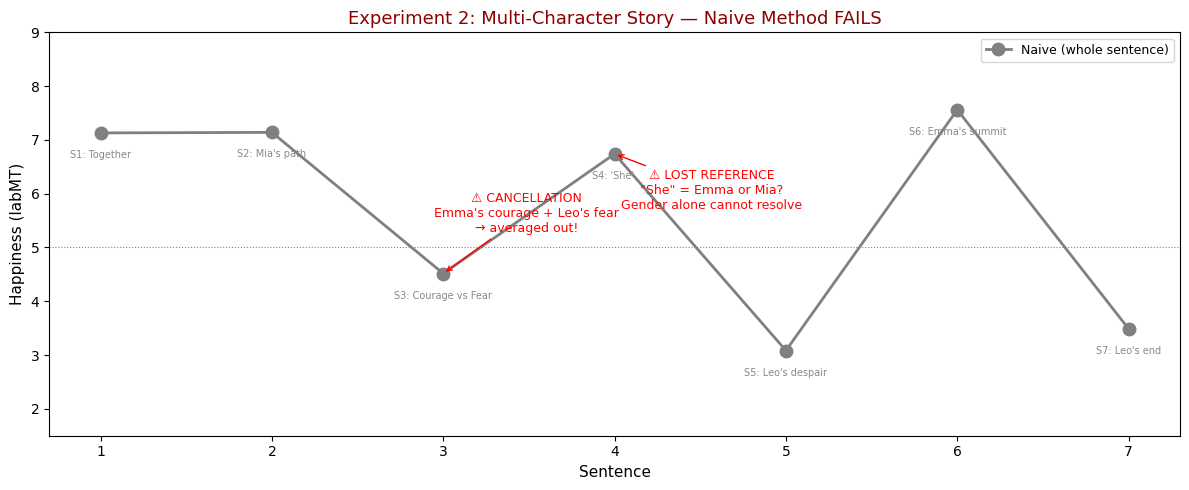


❌ Two failure modes:
   1. Sentiment CANCELLATION — S3 averages courage + fear → flat
   2. Pronoun LOSS — S4 'She' can't be assigned to Emma → data gap

   Simple filtering causes NARRATIVE TENSION ERASURE.


In [16]:
multi_story = [
    "Emma, Leo and Mia began their adventure together with shared excitement.",      # S1: all three positive
    "Mia found a safe path, felt great relief and hope, and went home afterwards.",                            # S2: Mia positive (last female = Mia)
    "While Emma celebrated her courage, Leo was consumed by terrible fear and agony.",  # S3: CONFLICT (last female = Emma)
    "She pressed forward with brilliant determination.",                                # S4: pronoun — Mia or Emma?
    "Leo fell into a dark pit of despair and suffered alone.",                          # S5: Leo negative
    "Emma reached the glorious summit and laughed with triumphant joy.",                # S6: Emma triumph
    "Leo was lost forever in the cruel and hopeless darkness.",                         # S7: Leo tragic end
]

sentence_labels = [
    "S1: Together", "S2: Mia's path", "S3: Courage vs Fear",
    "S4: 'She' ", "S5: Leo's despair", "S6: Emma's summit", "S7: Leo's end"
]

# Naive approach: just compute happiness per sentence
naive_scores = [happiness(s) for s in multi_story]

for i, (s, sc) in enumerate(zip(multi_story, naive_scores)):
    contribs = word_contributions(s)
    print(f"S{i+1} [h={sc:.2f}]: {', '.join(f'{w}({v:.1f})' for w, v in contribs)}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, 8), naive_scores, "o-", color="gray", linewidth=2, markersize=9, label="Naive (whole sentence)")
ax.axhline(5.0, color="gray", linestyle=":", linewidth=0.8)

# Highlight the two failure points
ax.annotate("⚠️ CANCELLATION\nEmma's courage + Leo's fear\n→ averaged out!",
            (3, naive_scores[2]), textcoords="offset points", xytext=(60, 30),
            fontsize=9, color="red", ha="center",
            arrowprops=dict(arrowstyle="->", color="red"))
ax.annotate('⚠️ LOST REFERENCE\n"She" = Emma or Mia?\nGender alone cannot resolve',
            (4, naive_scores[3]), textcoords="offset points", xytext=(70, -40),
            fontsize=9, color="red", ha="center",
            arrowprops=dict(arrowstyle="->", color="red"))

for i, lbl in enumerate(sentence_labels):
    ax.annotate(lbl, (i+1, naive_scores[i]), textcoords="offset points",
                xytext=(0, -18), ha="center", fontsize=7, color="#888")

ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Happiness (labMT)", fontsize=11)
ax.set_title("Experiment 2: Multi-Character Story — Naive Method FAILS", fontsize=13, color="darkred")
ax.set_ylim(1.5, 9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n❌ Two failure modes:")
print("   1. Sentiment CANCELLATION — S3 averages courage + fear → flat")
print("   2. Pronoun LOSS — S4 'She' can't be assigned to Emma → data gap")
print("\n   Simple filtering causes NARRATIVE TENSION ERASURE.")



As we can see, S1, S3, and S4 either contain no character names or multiple character names. How to resolve the issues ?
## 3. Coreference Resolution + Dependency Parsing

### Solution A: Coreference Resolution
Link pronouns back to their antecedents: *"She"* → *"Emma"*


### Packages for coreference resolution

The pipeline uses two Python packages to resolve pronouns and other references to characters:

**fastcoref** is a neural coreference resolution model that plugs into spaCy. It resolves pronouns (*she*, *he*, *they*) and other mentions to their referents (e.g. *She* → *Emma*). We use the `biu-nlp/lingmess-coref` model.

**gender-guesser** is a lightweight library that infers gender from first names. It is used to support rule-based pronoun resolution (e.g. *she* → most recent female character) before running the neural model.



In [38]:
%%capture
! pip install fastcoref -q
! pip install gender-guesser -q
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [39]:
import fastcoref
import gender_guesser

print("✅ fastcoref installed successfully.")
print("✅ gender-guesser installed successfully.")

✅ fastcoref installed successfully.
✅ gender-guesser installed successfully.


This cell runs the full coreference pipeline on the story text. It loads spaCy and fastcoref, then defines and runs `fully_automated_pipeline`, which is divided into four steps.
*   extracts character names via NER;
*   infers gender for those names;
*   runs fastcoref to resolve pronouns, prints that output, then diagnoses each sentence against our character list and applies rule-based she/he correction where fastcoref disagrees with our genders;
*   builds the character→sentence appearance map (V1). 
The cell then prints V1 and the final resolved sentences.

In [31]:
import spacy
import re
import gender_guesser.detector as gender
from fastcoref import spacy_component

# If nlp is not loaded yet, load it (this cell can be run alone without running other cells first)
if 'nlp' not in globals():
    nlp = spacy.load("en_core_web_sm")

# Add fastcoref to nlp pipeline
if "fastcoref" not in nlp.pipe_names:
    nlp.add_pipe("fastcoref", config={"model_architecture": "LingMessCoref", "model_path": "biu-nlp/lingmess-coref"})


def fully_automated_pipeline(raw_text):
    """
    Fully automated pipeline. Expects raw_text (e.g. " ".join(multi_story) when using the pre-defined sentence list).
    """
    print(" Starting coreference resolution")
    
    clean_text = raw_text.strip()
    
    # ==========================================
    # Step 1: AI auto-extract character entities (NER)
    # ==========================================
    with nlp.select_pipes(disable=(["fastcoref"] if "fastcoref" in nlp.pipe_names else [])):
        doc = nlp(clean_text)  # <--- Use cleaned clean_text here
        
    characters = set()
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            characters.add(ent.text.strip()) 
    characters = list(characters)
    print(f"[AI-extracted characters]: {characters}")

    # ==========================================
    # Step 2: Auto-infer character gender
    # ==========================================
    d = gender.Detector()
    char_gender = {}
    for char in characters:
        # For English names, first name is usually best for gender
        first_name = char.split()[0] 
        guess = d.get_gender(first_name.capitalize())
        
        if guess in ['female', 'mostly_female']:
            char_gender[char] = 'female'
        elif guess in ['male', 'mostly_male']:
            char_gender[char] = 'male'
        else:
            char_gender[char] = 'unknown'
            
    print(f"[AI-inferred gender]: {char_gender}")

    # ==========================================
    # Step 3: Coreference — fastcoref first, then diagnose and fix with rule if needed
    # ==========================================
    sentences = [sent.text for sent in doc.sents]
    original_sentences = list(sentences)
    
    # 3a. Run fastcoref on original text → get coref-resolved sentences
    full_text = " ".join(sentences)
    if "fastcoref" in nlp.pipe_names:
        doc_coref = nlp(full_text, component_cfg={"fastcoref": {'resolve_text': True}})
        with nlp.select_pipes(disable=["fastcoref"]):
            resolved_doc = nlp(doc_coref._.resolved_text)
        coref_sents = [sent.text for sent in resolved_doc.sents]
    else:
        coref_sents = list(sentences)
    
    print("=== Fastcoref output (before diagnosis) ===")
    for i, s in enumerate(coref_sents):
        print(f"  S{i+1}: {s}")
    print()
    
    # 3b. Rule-based she/he replacement (for diagnosis and fallback)
    last_seen = {"female": None, "male": None}
    rule_sents = []
    for sent in sentences:
        sent_lower = sent.lower()
        for char in characters:
            if char.lower() in sent_lower and char_gender[char] in ["female", "male"]:
                last_seen[char_gender[char]] = char
        new_sent = sent
        if last_seen["female"]:
            new_sent = re.sub(r'\b(She|she)\b', last_seen["female"], new_sent)
        if last_seen["male"]:
            new_sent = re.sub(r'\b(He|he)\b', last_seen["male"], new_sent)
        rule_sents.append(new_sent)
    
    # 3c. Diagnose: if fastcoref’s pronoun→name disagrees with our char_gender, force rule for that sentence
    print("=== Diagnosis (check against character list and gender) ===")
    final_sents = []
    for i, orig in enumerate(original_sentences):
        coref_sent = coref_sents[i] if i < len(coref_sents) else orig
        rule_sent = rule_sents[i]
        names_in_coref = [c for c in characters if c in coref_sent]
        has_she = " she " in orig.lower() or orig.lower().startswith("she ")
        has_he = " he " in orig.lower() or orig.lower().startswith("he ")
        use_rule = False
        reason = ""
        if has_she and not any(char_gender.get(c) == "female" for c in names_in_coref):
            use_rule = True
            reason = "original has 'she' but fastcoref did not resolve to a female in our list; using rule (she to last-seen female)"
        if has_he and not any(char_gender.get(c) == "male" for c in names_in_coref):
            use_rule = True
            reason = "original has 'he' but fastcoref did not resolve to a male in our list; using rule (he to last-seen male)"
        if use_rule:
            print(f"  S{i+1}: Mismatch — {reason}")
        else:
            print(f"  S{i+1}: Match; no change.")
        final_sents.append(rule_sent if use_rule else coref_sent)
    print()

    # ==========================================
    # Step 4: Count appearance frequency (for plotting emotional arcs)
    # ==========================================
    resolved_appearances = {c: [] for c in characters}
    for i, sent in enumerate(final_sents):
        sent_lower = sent.lower()
        for char in characters:
            if char.lower() in sent_lower:
                resolved_appearances[char].append(i)

    print("Analysis complete!\n")
    return characters, char_gender, original_sentences, final_sents, resolved_appearances

# --- Run full pipeline, store coreference result for later use ---

chars, genders, sents_original, sents_resolved, appearances = fully_automated_pipeline(" ".join(multi_story))
sents = sents_original
characters = chars

# V1 = coreference assignment (character → sentence indices), for dependency parsing and aggregation
print("=== Coreference assignment (V1): character → sentences ===")
for c, idx in appearances.items():
    labels = [f"S{i+1}" for i in idx]
    print(f"  {c}: " + ", ".join(labels))

print("\n=== Final resolved version (after diagnosis; pronouns → character names) ===")
for i, s in enumerate(sents_resolved):
    print(f"  S{i+1}: {s}")


03/14/2026 22:18:42 - INFO - 	 Tokenize 1 inputs...


 Starting coreference resolution
[AI-extracted characters]: ['Emma', 'Leo', 'Mia']
[AI-inferred gender]: {'Emma': 'female', 'Leo': 'male', 'Mia': 'female'}


Map: 100%|██████████| 1/1 [00:00<00:00, 137.21 examples/s]
03/14/2026 22:18:42 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:07<00:00,  7.11s/it]

=== Fastcoref output (before diagnosis) ===
  S1: Emma, Leo and Mia began Emma, Leo and Mia's adventure together with shared excitement.
  S2: Mia found a safe path, felt great relief and hope, and went home afterwards.
  S3: While Emma celebrated Emma's courage, Leo was consumed by terrible fear and agony.
  S4: Leo pressed forward with brilliant determination.
  S5: Leo fell into a dark pit of despair and suffered alone.
  S6: Emma reached the glorious summit and laughed with triumphant joy.
  S7: Leo was lost forever in the cruel and hopeless darkness.

=== Diagnosis (check against character list and gender) ===
  S1: Match; no change.
  S2: Match; no change.
  S3: Match; no change.
  S4: Mismatch — original has 'she' but fastcoref did not resolve to a female in our list; using rule (she to last-seen female)
  S5: Match; no change.
  S6: Match; no change.
  S7: Match; no change.

Analysis complete!

=== Coreference assignment (V1): character → sentences ===
  Emma: S1, S3, S4, S6
  

### Solution B: Dependency Parsing
It analyzes the grammatical structure of a sentence by labeling relationships between words (e.g. subject–verb–object, modifiers). Here we visualize the dependency trees for S1 and S3 so you can see how the parser separates clauses and attaches words to heads.

In [ ]:
import IPython
from IPython.display import display, HTML


import sys
sys.modules['IPython.core.display'] = IPython.display 

import spacy
from spacy import displacy


# --- Visualizing the Syntactic Structure ---

# 1. Process and visualize Sentence S1
print("Dependency Tree for Sentence S1:")
doc_s1 = nlp(multi_story[0])

# We use jupyter=True to render the SVG directly in the notebook.
# 'compact': True creates a more condensed, readable tree.
displacy.render(doc_s1, style="dep", jupyter=True, options={"compact": True, "distance": 90})

# 2. Process and visualize Sentence S3
print("\nDependency Tree for Sentence S3:")
doc_s3 = nlp(multi_story[2])

# Render the dependency tree for S3
displacy.render(doc_s3, style="dep", jupyter=True, options={"compact": True, "distance": 90})


03/14/2026 22:19:04 - INFO - 	 Tokenize 1 inputs...


Dependency Tree for Sentence S1:


Map: 100%|██████████| 1/1 [00:00<00:00, 261.02 examples/s]
03/14/2026 22:19:05 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:06<00:00,  6.51s/it]


03/14/2026 22:19:11 - INFO - 	 Tokenize 1 inputs...



Dependency Tree for Sentence S3:


Map: 100%|██████████| 1/1 [00:00<00:00, 239.74 examples/s]
03/14/2026 22:19:11 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:06<00:00,  6.57s/it]


### Understanding Dependency Relations

Dependency parsing analyzes the grammatical structure of a sentence by showing which words depend on which other words. Each arrow in the visualization points from a 'head' word to a 'dependent' word, and the label on the arrow describes the grammatical relationship between them.

Here are some common dependency labels you might see and what they generally mean:

*   **ROOT**: The main verb or head of the entire sentence. Every other word in the sentence eventually depends on the ROOT.
*   **nsubj** (nominal subject): The subject of a finite verb. (e.g., 'Emma' in 'Emma began')
*   **obj** (object): The direct object of a verb. (e.g., 'adventure' in 'began adventure')
*   **advmod** (adverbial modifier): An adverbial modifying a verb, adjective, or other adverb. (e.g., 'together' in 'began together')
*   **amod** (adjectival modifier): An adjective modifying a noun. (e.g., 'shared' in 'shared excitement')
*   **compound**: A compound word or a multi-word expression. (e.g., part of a named entity)
*   **det** (determiner): A determiner modifying a noun. (e.g., 'their' in 'their adventure')
*   **prep** (prepositional modifier): The head of a prepositional phrase. (e.g., 'with' in 'with excitement')
*   **pobj** (object of preposition): The object of a preposition. (e.g., 'excitement' in 'with excitement')
*   **conj** (conjunct): A word joined by a coordinating conjunction. (e.g., 'Leo' and 'Mia' might be 'conj' to 'Emma' if they are listed together)
*   **cc** (coordinating conjunction): The coordinating conjunction itself. (e.g., 'and' linking 'Emma, Leo and Mia')
*   **punct** (punctuation): Punctuation marks.
*   **advcl** (adverbial clause modifier): A clause that modifies a verb or a clause, usually indicating time, cause, or condition. (e.g., 'While Emma celebrated...' in S3)
*   **ccomp** (clausal complement): A clausal complement of a verb or adjective.


### The `extract_character_clauses` Rule Explained:

This function (see below) employs a rule-based approach using spaCy's dependency parser to isolate parts of a sentence relevant to a specific character. The core steps are:

**S1: "Emma, Leo and Mia began their adventure together with shared excitement."**

**S3: "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."**

### 1. Character Identification:
*   This step simply scans the sentence to find explicit mentions of our predefined characters.

*   'Emma', 'Leo', and 'Mia' are all identified.
*   'Emma' and 'Leo' are identified.

### 2. Head Token Traversal:
*  For each identified character, the function starts from the character's name and climbs up the dependency tree (moving from a word to the word it grammatically depends on). It stops climbing when it reaches a token whose dependency label is `ROOT` (the main verb of the entire sentence), `advcl` (adverbial clause), or `ccomp` (clausal complement).

*  For 'Emma', 'Leo', and 'Mia', the traversal climbs past the conjunctions ('and') and finds that the verb **'began'** is the common head. Since 'began' is the `ROOT` of the sentence, the traversal stops there for all three characters.
*   For 'Emma', the traversal climbs up to the verb **'celebrated'**. Since 'celebrated' is the head of an `advcl` (the 'While' clause), the traversal stops there.
*  For 'Leo', the traversal climbs up to the verb **'consumed'**. Since 'consumed' is the `ROOT` of the entire sentence, the traversal stops there.

### 3. Subtree Extraction:
*    Once the appropriate 'head' token (e.g., `ROOT`, `advcl`, `ccomp`) is found for a character, the function extracts all the words that grammatically depend on that head. This forms the clause associated with the character.


*    For 'Emma', 'Leo', and 'Mia', since 'began' (the `ROOT`) was their common head, the initial extracted subtree for each would be the entire sentence: "Emma, Leo and Mia began their adventure together with shared excitement."
*    For 'Emma', the subtree governed by 'celebrated' is extracted: "While Emma celebrated her courage."
*    For 'Leo', the subtree governed by 'consumed' (the `ROOT`) is initially extracted. Without further refinement, this would also include the "While Emma celebrated her courage" part.

### 4. Cross-Contamination Prevention:
*  This is a crucial *refinement* step that specifically applies if a character's identified head from Step 2 is the `ROOT` of the *entire sentence*. It then examines the *direct children* of that `ROOT` to see if any of them are `advcl` or `ccomp` clauses that *contain the name of another character*. If so, those `advcl` or `ccomp` clauses are explicitly excluded from the current character's extracted text to prevent their sentiment from mixing.

*    For 'Emma', 'Leo', and 'Mia', their head 'began' is the `ROOT`. However, S1 does not contain any distinct `advcl` or `ccomp` clauses that specifically feature *other* characters. All three are part of the main `ROOT` clause. Therefore, this step does not exclude any parts of the sentence; the full shared sentence remains attributed to each character, which is the correct outcome for their shared experience.
*    This step does *not* directly apply to Emma's clause, because 'celebrated' (her head) is an `advcl`, not the `ROOT` of the entire sentence.
*    For 'Leo', his head 'consumed' *is* the `ROOT`. So, the function checks the direct children of 'consumed'. It finds that the clause "While Emma celebrated her courage" is an `advcl` child of 'consumed', and it contains the name 'Emma' (another character). Therefore, this `advcl` clause is **excluded** from Leo's extracted text. This leaves Leo with just the part relevant to him: "Leo was consumed by terrible fear and agony."

This final step ensures that even when one character's action is the primary focus (the ROOT) of a sentence, we don't accidentally attribute the distinct actions or feelings of other characters (expressed in subordinate clauses) to them.

In [ ]:
def extract_character_clauses(sentence, characters):
    """Split a sentence into character-specific clauses via dependency parsing (no coreference)."""
    # Dependency parsing only (disable fastcoref); build character set and output dict.
    with nlp.select_pipes(disable=(["fastcoref"] if "fastcoref" in nlp.pipe_names else [])):
        doc = nlp(sentence)
    char_set = set(characters)
    char_words = {c: [] for c in characters}

    # Step 3 helper: return subtree text of a token, optionally excluding indices (used after Step 4 in the loop).
    def get_subtree_text(tok, excluded_indices=None):
        if excluded_indices is None:
            excluded_indices = set()
        return " ".join(t.text for t in tok.subtree if t.i not in excluded_indices)

    for token in doc:
        # Step 1: Character identification — scan the sentence for tokens that match our predefined character names.
        if token.text in char_set:
            # Step 2: Head token traversal — from the character's name climb up the dependency tree until ROOT, advcl, or ccomp.
            head = token
            while head.dep_ not in ("ROOT", "advcl", "ccomp") and head.head != head:
                head = head.head
            other_chars = char_set - {token.text}
            excluded = set()
            # Step 4: Cross-contamination prevention — if head is ROOT, exclude advcl/ccomp children that mention other characters.
            if head.dep_ == "ROOT":
                for child in head.children:
                    if child.dep_ in ("advcl", "ccomp"):
                        child_text = " ".join(t.text for t in child.subtree)
                        if any(oc in child_text for oc in other_chars):
                            excluded.update(t.i for t in child.subtree)
            # Step 3: Subtree extraction — get clause text for this character (with exclusions from Step 4 applied).
            subtree_text = get_subtree_text(head, excluded)
            char_words[token.text].append(subtree_text)

    return char_words

# Use sents, chars from pipeline (run the pipeline cell first)
# Demonstrate on S1 — the initial sentence with all characters
s1 = sents[0] if len(sents) > 0 else ""
print(f"Original S1: \"{s1}\"")
print()

clauses_s1 = extract_character_clauses(s1, chars)
for char, parts in clauses_s1.items():
    if parts:
        combined = " ".join(parts)
        h = happiness(combined)
        contribs = word_contributions(combined)
        words_str = ", ".join(f"{w}({v:.1f})" for w, v in contribs)
        print(f"  {char}'s clause in S1: \"{combined}\"")
        print(f"    → happiness = {h:.2f}  [{words_str}]")
        print()

print("--- Now demonstrating on S3 ---")

# Demonstrate on S3 — the conflict sentence
s3 = sents[2] if len(sents) > 2 else ""
print(f"Original S3: \"{s3}\"")
print()

clauses_s3 = extract_character_clauses(s3, chars)
for char, parts in clauses_s3.items():
    if parts:
        combined = " ".join(parts)
        h = happiness(combined)
        contribs = word_contributions(combined)
        words_str = ", ".join(f"{w}({v:.1f})" for w, v in contribs)
        print(f"  {char}'s clause in S3: \"{combined}\"")
        print(f"    → happiness = {h:.2f}  [{words_str}]")
        print()

print("Dependency parsing helps separate character-specific sentiment in sentences like S1 and S3!")


# ========== Build V2 from V1 + dependency parsing (char → [(sent_idx, text)], for Putting it all together to do sentiment only) ==========
assignment_v2 = {c: [] for c in chars}
for char in chars:
    for sent_idx in appearances[char]:
        sent = sents[sent_idx]
        other_chars_present = any(oc.lower() in sent.lower() for oc in chars if oc != char)
        if other_chars_present:
            clauses = extract_character_clauses(sent, chars)
            text_used = " ".join(clauses[char]) if clauses.get(char) else sent
        else:
            text_used = sent
        assignment_v2[char].append((sent_idx, text_used))
print("\n=== V2 (clause-level assignment after dependency parsing) updated ===")
for c in assignment_v2:
    print(f"  {c}:")
    for sent_idx, text_used in assignment_v2[c]:
        label = f"S{sent_idx+1}"
        print(f"    {label}: {text_used!r}")
    print()


Original S1: "Emma, Leo and Mia began their adventure together with shared excitement."

  Emma's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

  Leo's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

  Mia's clause in S1: "Emma , Leo and Mia began their adventure together with shared excitement ."
    → happiness = 7.13  [adventure(7.3), together(6.8), shared(6.8), excitement(7.6)]

--- Now demonstrating on S3 ---
Original S3: "While Emma celebrated her courage, Leo was consumed by terrible fear and agony."

  Emma's clause in S3: "While Emma celebrated her courage"
    → happiness = 7.63  [celebrated(7.8), courage(7.5)]

  Leo's clause in S3: ", Leo was consumed by terrible fear and agony ."
    → happiness = 2.44  [terrible(2.

### Putting It All Together: Character-Specific Arcs

Now we calculate the character arcs using the updated assignments after coreference resolution and dependency parsing.

Character arcs (sentence index → happiness):
  Emma: S1=7.13, S3=7.63, S4=6.74, S6=7.56
  Leo: S1=7.13, S3=2.44, S5=3.08, S7=3.49
  Mia: S1=7.13, S2=7.14


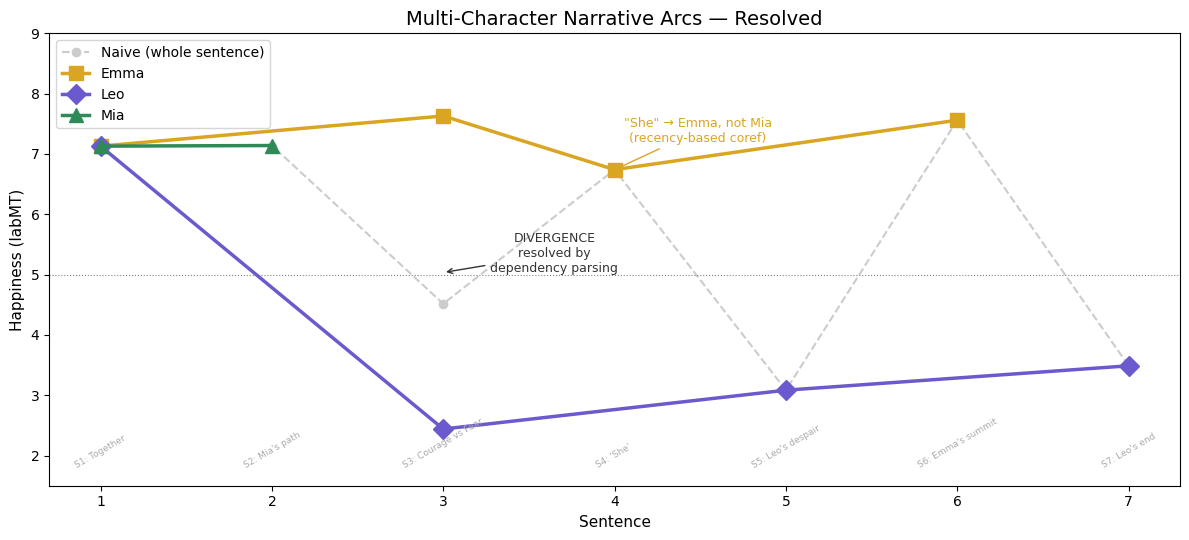


Emma's arc: hope → courage → determination → triumph (ascending)
Leo's arc:  hope → fear → despair → lost forever (descending)
Mia's arc:  hope → relief (brief appearance)


In [37]:

arcs = {c: {} for c in characters}
for char in characters:
    for sent_idx, text_used in assignment_v2[char]:
        arcs[char][sent_idx] = happiness(text_used)

# Run pipeline (get V1) and dependency parsing cell (get V2) first

print("Character arcs (sentence index → happiness):")
for char, arc in arcs.items():
    points = [f"S{i+1}={v:.2f}" for i, v in sorted(arc.items())]
    print(f"  {char}: {', '.join(points)}")

fig, ax = plt.subplots(figsize=(12, 5.5))

# Plot naive (gray, dashed)
ax.plot(range(1, 8), naive_scores, "o--", color="#ccc", linewidth=1.5,
        markersize=6, label="Naive (whole sentence)", zorder=1)

# Plot character arcs
colors = {"Emma": "#DAA520", "Leo": "#6A5ACD", "Mia": "#2E8B57"}
markers = {"Emma": "s", "Leo": "D", "Mia": "^"}

for char in characters:
    arc = arcs[char]
    xs = [i + 1 for i in sorted(arc.keys())]
    ys = [arc[i] for i in sorted(arc.keys())]
    ax.plot(xs, ys, f"{markers[char]}-", color=colors[char],
            linewidth=2.5, markersize=10, label=char, zorder=3)

ax.axhline(5.0, color="gray", linestyle=":", linewidth=0.8)

# Annotate the key divergence
ax.annotate("DIVERGENCE\nresolved by\ndependency parsing",
            xy=(3, (arcs["Emma"].get(2, 5) + arcs["Leo"].get(2, 5)) / 2),
            textcoords="offset points", xytext=(80, 0),
            fontsize=9, ha="center", color="#333",
            arrowprops=dict(arrowstyle="->", color="#333"))
ax.annotate('"She" → Emma, not Mia\n(recency-based coref)',
            xy=(4, arcs["Emma"].get(3, 5)),
            textcoords="offset points", xytext=(60, 20),
            fontsize=9, ha="center", color=colors["Emma"],
            arrowprops=dict(arrowstyle="->", color=colors["Emma"]))

for i, lbl in enumerate(sentence_labels):
    ax.annotate(lbl, (i+1, 1.8), ha="center", fontsize=6.5, color="#aaa", rotation=30)

ax.set_xlabel("Sentence", fontsize=11)
ax.set_ylabel("Happiness (labMT)", fontsize=11)
ax.set_title("Multi-Character Narrative Arcs — Resolved", fontsize=14)
ax.set_ylim(1.5, 9)
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

print("\nEmma's arc: hope → courage → determination → triumph (ascending)")
print("Leo's arc:  hope → fear → despair → lost forever (descending)")
print("Mia's arc:  hope → relief (brief appearance)")


---
## Summary

| Step | Method | Capability | Limitation |
|------|--------|------------|------------|
| 1 | labMT word matching | Single-character arcs | Can't handle pronouns or multi-character sentences |
| 2 | + Coreference resolution | Links "She" → Emma (recency-based, not just gender) | Still averages conflicting emotions in shared sentences |
| 3 | + Dependency parsing | Splits S3 into Emma's courage vs Leo's fear; excludes cross-character advcl |  |



---




## Related Studies


***

## labMT Lexicon

**Dodds, Peter Sheridan, et al.** “Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter.” *PLOS ONE*, vol. 6, no. 12, 2011, e26752.  
<https://doi.org/10.1371/journal.pone.0026752>   
**Dodds, Peter Sheridan, et al.** “Human Language Reveals a Universal Positivity Bias.” *Proceedings of the National Academy of Sciences*, vol. 112, no. 8, 2015, pp. 2389–2394.  
<https://doi.org/10.1073/pnas.1411678112>   

## Story Shapes / Emotional Arcs

**Reagan, Andrew J., et al.** “The Emotional Arcs of Stories Are Dominated by Six Basic Shapes.” *EPJ Data Science*, vol. 5, 2016, article 31.  
<https://doi.org/10.1140/epjds/s13688-016-0093-1>   

**Jockers, Matthew.** The Rest of the Story. 25 Feb. 2015, <https://www.matthewjockers.net/2015/02/25/the-rest-of-the-story/.> 

**Vishnubhotla, Krishnapriya, et al.** “The Emotion Dynamics of Literary Novels.” *Findings of the Association for Computational Linguistics: ACL 2024*, edited by Lun-Wei Ku et al., Association for Computational Linguistics, 2024, pp. 2557–74. ACLWeb, <https://doi.org/10.18653/v1/2024.findings-acl.150.>



***

## spaCy

**Honnibal, Matthew, et al.** *spaCy: Industrial‑Strength Natural Language Processing in Python.* Explosion AI, 2020. Zenodo,  
<https://doi.org/10.5281/zenodo.1212303>    

*(This is the **official citation recommended by the developers**.)*

***

## BookNLP

**Bamman, David, Ted Underwood, and Noah A. Smith.** “A Bayesian Mixed Effects Model of Literary Character.” *Proceedings of the 52nd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)*, Association for Computational Linguistics, 2014, pp. 370–379.  
<https://aclanthology.org/P14-1035/>    
***

## Kurt Vonnegut

**Vonnegut, Kurt.** *Palm Sunday: An Autobiographical Collage.* Delacorte Press, 1981.  
<https://openlibrary.org/books/OL4112281M/Palm_Sunday>    



